<a href="https://colab.research.google.com/github/AriArlerus/Project/blob/bam/POA_Ultrasonic_Real_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Measurement Enhancement of Ultrasonic Sensor
# using Pelican Optimization Algorithm (POA)

**อ้างอิง:** Khaleel et al. (2024), Indonesian Journal of Science & Technology, 9(1), 145-162

---
**Dataset:** `Distance(CM) - SensorData.csv`

In [1]:
# ===== Cell 1: Import Libraries =====
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
import io
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# ===== Cell 2: Load Dataset (รวมหลายชีตพร้อมกัน) =====


# 🔥 ใส่ระยะที่ต้องการรวม
DISTANCE_LIST = [20, 30, 40, 50, 300]

GID_MAP = {
    20:  "232904181",
    30:  "874540621",
    40:  "370951230",
    50:  "481672648",
    300: "96634151",
}

BASE_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vR2niB432N1Z2rFE3-SggNaLKS2jJ5UyVVWlmIvlEvshexcMACSd0IpsL-UsV-Q2AMyBr_ETi1VxUw3/pub?output=csv&single=true&gid="

all_dfs = []

for dist in DISTANCE_LIST:
    if dist not in GID_MAP:
        raise ValueError(f"Distance {dist} cm not found in GID_MAP")

    sheet_url = BASE_URL + GID_MAP[dist]
    response = requests.get(sheet_url)
    response.raise_for_status()

    df_temp = pd.read_csv(io.StringIO(response.content.decode("utf-8")))
    df_temp.columns = df_temp.columns.str.strip()

    required_cols = ["Measured (cm)", "Desired (cm)", "Index"]
    for col in required_cols:
        if col not in df_temp.columns:
            raise KeyError(f"Missing column '{col}' in sheet {dist} cm")

    df_temp = df_temp.sort_values(by="Index").reset_index(drop=True)

    # เพิ่มคอลัมน์ระยะต้นทาง กันงงทีหลัง
    df_temp["Source Distance (cm)"] = dist

    all_dfs.append(df_temp)

# รวมทุกชีต
df = pd.concat(all_dfs, ignore_index=True)

# extract
measured_distances = df["Measured (cm)"].astype(float).values
desired_distances  = df["Desired (cm)"].astype(float).values
n_samples = len(df)

print(f"Loaded total {n_samples} rows from distances: {DISTANCE_LIST}")
print(df.head())
print(df["Desired (cm)"].value_counts().sort_index())

Loaded total 2151 rows from distances: [20, 30, 40, 50, 300]
            Timestamp          Sensor  Index  Measured (cm)  Desired (cm)  \
0  4/12/2026 22:41:45  SensorData20cm      1        19.3970            20   
1  4/12/2026 22:41:51  SensorData20cm      2        19.4072            20   
2  4/12/2026 22:41:56  SensorData20cm      3        19.4140            20   
3  4/12/2026 22:42:01  SensorData20cm      4        19.4106            20   
4  4/12/2026 22:42:06  SensorData20cm      5        19.3970            20   

   Error (cm)  Abs Error (cm)  Source Distance (cm)  
0   -0.603001        0.603001                    20  
1   -0.592800        0.592800                    20  
2   -0.586002        0.586002                    20  
3   -0.589401        0.589401                    20  
4   -0.603001        0.603001                    20  
Desired (cm)
20     431
30     431
40     429
50     431
300    429
Name: count, dtype: int64


In [3]:
# ===== Cell 3: Classical Method =====
# Equation (9): error = measured_distance - desired_distance

classical_errors = measured_distances - desired_distances
classical_abs_errors = np.abs(classical_errors)

print('=' * 60)
print('Classical Method — Error per row')
print('=' * 60)
print(f'{"Row":<6} {"Desired":>10} {"Measured":>14} {"Error":>14}')
print('-' * 50)
for i in range(n_samples):
    print(f'{i+1:<6} {desired_distances[i]:>10.1f} {measured_distances[i]:>14.6f} {classical_errors[i]:>14.6f}')

print('=' * 60)
print(f'Min  |error| : {classical_abs_errors.min():.8f} cm')
print(f'Max  |error| : {classical_abs_errors.max():.8f} cm')
print(f'Mean |error| : {classical_abs_errors.mean():.8f} cm')
print('=' * 60)

Classical Method — Error per row
Row       Desired       Measured          Error
--------------------------------------------------
1            20.0      19.397000      -0.603000
2            20.0      19.407200      -0.592800
3            20.0      19.414000      -0.586000
4            20.0      19.410600      -0.589400
5            20.0      19.397000      -0.603000
6            20.0      19.397000      -0.603000
7            20.0      19.410600      -0.589400
8            20.0      19.397000      -0.603000
9            20.0      19.397000      -0.603000
10           20.0      19.417400      -0.582600
11           20.0      19.410600      -0.589400
12           20.0      19.410600      -0.589400
13           20.0      19.397000      -0.603000
14           20.0      19.417400      -0.582600
15           20.0      19.397000      -0.603000
16           20.0      19.414000      -0.586000
17           20.0      19.407200      -0.592800
18           20.0      19.400400      -0.599600
19  

In [4]:
# ===== Cell 4: Pelican Optimization Algorithm (POA) =====
# ปรับให้ใกล้ paper มากขึ้น

# Parameters from paper (Table 2)
n = 431         # number of POA population
m = 2           # [measured, desired]
T = 10          # maximum iteration
R = 0.2         # radius coefficient

# bounds จากช่วงข้อมูลจริง
lb_meas = measured_distances.min()
ub_meas = measured_distances.max()
lb_des  = desired_distances.min()
ub_des  = desired_distances.max()

# Fitness Function from Eq. (9)
# error = measured_distance - desired_distance
# ใช้ absolute error เพื่อให้รายงานผลเป็น cm
def fitness_function(measured, desired):
    return abs(measured - desired)

# ===== Initialization (Eq. 1, 2, 3) =====
# ใน paper pelican คือ candidate solution ไม่ใช่ 1 แถวข้อมูล
# ดังนั้นเราจะสุ่ม population ขนาด n จากช่วงข้อมูล
np.random.seed(42)

X = np.zeros((n, m))

# คอลัมน์ 0 = measured, คอลัมน์ 1 = desired
X[:, 0] = np.random.uniform(lb_meas, ub_meas, n)
X[:, 1] = np.random.uniform(lb_des,  ub_des,  n)

fitness = np.array([fitness_function(X[i, 0], X[i, 1]) for i in range(n)])

# เก็บประวัติ
best_fitness_history = []
mean_fitness_history = []
best_pelican_history = []

print('=' * 70)
print('POA Optimization (Paper-aligned version)')
print('=' * 70)
print(f'n={n}  m={m}  T={T}  R={R}')
print(f'Measured bounds: [{lb_meas:.4f}, {ub_meas:.4f}]')
print(f'Desired  bounds: [{lb_des:.4f}, {ub_des:.4f}]')
print('=' * 70)
print(f'{"Iter":<6} {"Best Fitness (cm)":<22} {"Best [measured, desired] (cm)"}')
print('-' * 70)

for t in range(1, T + 1):

    # ===== Phase 1: Exploration (Eq. 4-5) =====
    # random prey location in search space
    prey = np.array([
    np.random.uniform(lb_meas, ub_meas),
    np.random.uniform(lb_des,  ub_des)
    ])
    f_prey = fitness_function(prey[0], prey[1])

    X_p1 = X.copy()

    for i in range(n):
        I = np.random.choice([1, 2])
        for j in range(m):
            r = np.random.random()

            if f_prey < fitness[i]:
                X_p1[i, j] = X[i, j] + r * (prey[j] - I * X[i, j])
            else:
                X_p1[i, j] = X[i, j] + r * (X[i, j] - prey[j])

        # clip แยกแต่ละตัวแปร
        X_p1[i, 0] = np.clip(X_p1[i, 0], lb_meas, ub_meas)
        X_p1[i, 1] = np.clip(X_p1[i, 1], lb_des,  ub_des)

    fitness_p1 = np.array([fitness_function(X_p1[i, 0], X_p1[i, 1]) for i in range(n)])

    improved_p1 = fitness_p1 < fitness
    X[improved_p1] = X_p1[improved_p1]
    fitness[improved_p1] = fitness_p1[improved_p1]

    # ===== Phase 2: Exploitation (Eq. 6-7) =====
    X_p2 = X.copy()
    coeff = R * (1 - t / T)

    for i in range(n):
        for j in range(m):
            X_p2[i, j] = X[i, j] + coeff * (2 * np.random.random() - 1) * X[i, j]

        X_p2[i, 0] = np.clip(X_p2[i, 0], lb_meas, ub_meas)
        X_p2[i, 1] = np.clip(X_p2[i, 1], lb_des,  ub_des)

    fitness_p2 = np.array([fitness_function(X_p2[i, 0], X_p2[i, 1]) for i in range(n)])

    improved_p2 = fitness_p2 < fitness
    X[improved_p2] = X_p2[improved_p2]
    fitness[improved_p2] = fitness_p2[improved_p2]

    # ===== Save history =====
    best_idx_t = np.argmin(fitness)
    best_fit_t = fitness[best_idx_t]
    best_pel_t = X[best_idx_t].copy()

    best_fitness_history.append(best_fit_t)
    mean_fitness_history.append(np.mean(fitness))
    best_pelican_history.append(best_pel_t)

    print(f'{t:<6} {best_fit_t:<22.6e} [{best_pel_t[0]:.5f}, {best_pel_t[1]:.5f}]')

print('=' * 70)

final_best_idx = np.argmin(fitness)
final_best_fitness = fitness[final_best_idx]
final_best_pelican = X[final_best_idx]
best_iter = int(np.argmin(best_fitness_history)) + 1

print(f'\nBest fitness          : {final_best_fitness:.6e} cm')
print(f'Best pelican          : measured={final_best_pelican[0]:.6f}, desired={final_best_pelican[1]:.6f}')
print(f'Achieved at iteration : {best_iter}')

POA Optimization (Paper-aligned version)
n=431  m=2  T=10  R=0.2
Measured bounds: [19.3868, 397.1880]
Desired  bounds: [20.0000, 300.0000]
Iter   Best Fitness (cm)      Best [measured, desired] (cm)
----------------------------------------------------------------------
1      1.633321e-01           [70.55194, 70.38861]
2      1.737268e-03           [19.99826, 20.00000]
3      1.737268e-03           [19.99826, 20.00000]
4      1.737268e-03           [19.99826, 20.00000]
5      5.285998e-05           [20.00005, 20.00000]
6      5.285998e-05           [20.00005, 20.00000]
7      5.285998e-05           [20.00005, 20.00000]
8      5.285998e-05           [20.00005, 20.00000]
9      5.285998e-05           [20.00005, 20.00000]
10     5.285998e-05           [20.00005, 20.00000]

Best fitness          : 5.285998e-05 cm
Best pelican          : measured=20.000053, desired=20.000000
Achieved at iteration : 5


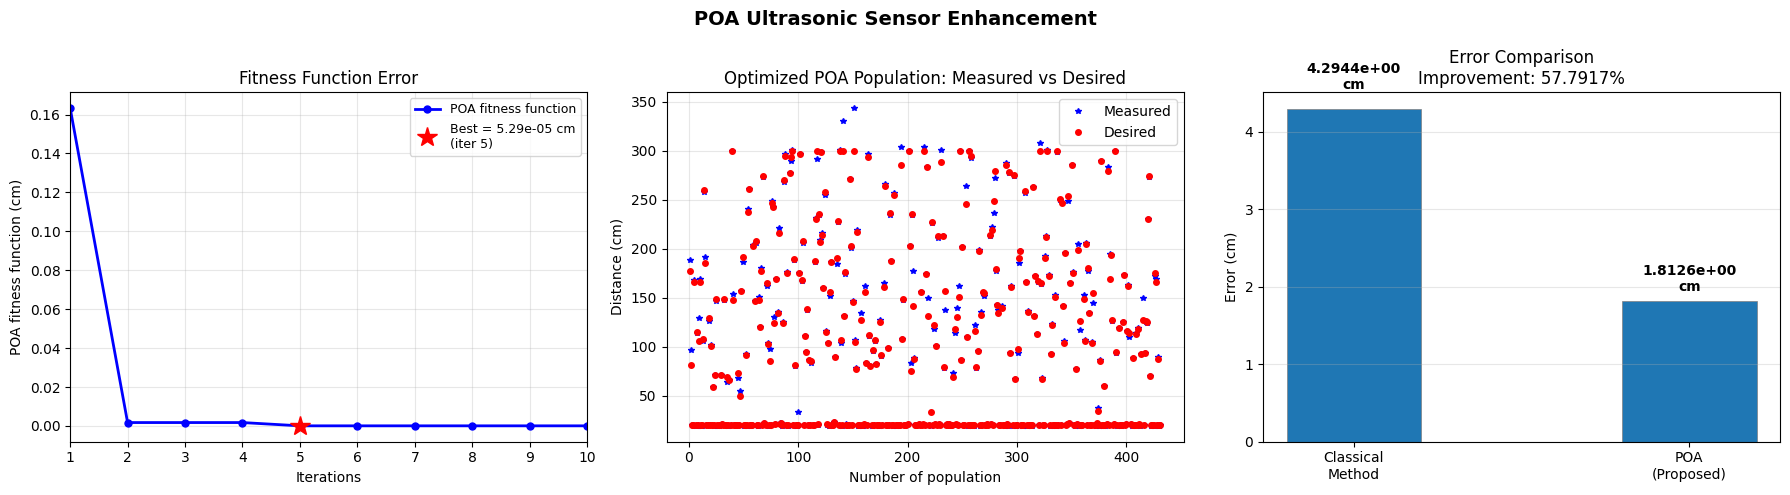

Figure saved: POA_results.png


In [5]:
# ===== Cell 5: Visualization =====

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax1, ax2, ax3 = axes
fig.suptitle('POA Ultrasonic Sensor Enhancement', fontsize=14, fontweight='bold')

# --- Plot 1: Fitness Function vs Iteration ---
ax1.plot(range(1, T+1), best_fitness_history, 'b-o',
         linewidth=2, markersize=5, label='POA fitness function')
ax1.plot(best_iter, best_fitness_history[best_iter-1], 'r*',
         markersize=15,
         label=f'Best = {best_fitness_history[best_iter-1]:.2e} cm\n(iter {best_iter})')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('POA fitness function (cm)')
ax1.set_title('Fitness Function Error')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([1, T])

# --- Plot 2: Best pelican only ---
ax2.plot(range(1, n+1), X[:, 0], 'b*', markersize=4, label='Measured')
ax2.plot(range(1, n+1), X[:, 1], 'ro', markersize=4, label='Desired')
ax2.set_xlabel('Number of population')
ax2.set_ylabel('Distance (cm)')
ax2.set_title('Optimized POA Population: Measured vs Desired')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Error Comparison ---
classical_errors = measured_distances - desired_distances
classical_val = np.mean(np.abs(classical_errors))
poa_errors = np.abs(X[:, 0] - X[:, 1])
poa_val = np.mean(poa_errors)
improvement = (1 - poa_val / classical_val) * 100 if classical_val > 0 else 0

bars = ax3.bar(['Classical\nMethod', 'POA\n(Proposed)'],
               [classical_val, poa_val],
               width=0.4, edgecolor='gray', linewidth=0.5)

for bar, val in zip(bars, [classical_val, poa_val]):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.05,
             f'{val:.4e}\ncm',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_ylabel('Error (cm)')
ax3.set_title(f'Error Comparison\nImprovement: {improvement:.4f}%')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('POA_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure saved: POA_results.png')

In [6]:
# ===== Cell 6: Final Report =====

classical_errors = measured_distances - desired_distances
classical_val = np.mean(np.abs(classical_errors))

poa_errors = np.abs(X[:, 0] - X[:, 1])
poa_val = np.mean(poa_errors)

improvement = (1 - poa_val / classical_val) * 100 if classical_val > 0 else 0

print('=' * 60)
print('FINAL REPORT')
print('=' * 60)
print(f'{"Method":<25} {"Error (cm)":<20} {"Improvement"}')
print('-' * 60)
print(f'{"Classical Method":<25} {classical_val:<20.8f} baseline')
print(f'{"Proposed POA":<25} {poa_val:<20.6e} {improvement:.4f}%')
print('=' * 60)

FINAL REPORT
Method                    Error (cm)           Improvement
------------------------------------------------------------
Classical Method          4.29441520           baseline
Proposed POA              1.812598e+00         57.7917%
